In [ ]:
!pip install qiskit qiskit_aer numpy scipy pylatexenc qiskit-algorithms qiskit-nature qiskit-ibm-runtime pyscf qiskit-nature[pyscf]

In [ ]:
import qiskit
import numpy as np
import matplotlib.pyplot as plt
from qiskit.circuit.library import TwoLocal
from qiskit.quantum_info import SparsePauliOp
from qiskit_aer import AerSimulator
from qiskit_algorithms import VQE
from qiskit.primitives import StatevectorEstimator as Estimator
from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.second_q.mappers import JordanWignerMapper,ParityMapper,TaperedQubitMapper
from qiskit_algorithms.optimizers import SPSA,COBYLA,L_BFGS_B,SLSQP
from qiskit_nature.second_q.circuit.library import UCCSD,HartreeFock,UCC
from qiskit_nature.second_q.transformers import ActiveSpaceTransformer
from qiskit_algorithms import NumPyMinimumEigensolver

In [ ]:
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel,depolarizing_error
from qiskit_ibm_runtime.fake_provider import FakeManilaV2,FakeCairoV2

from qiskit import transpile

In [ ]:
from qiskit_aer.primitives import Estimator as AerEstimator

In [ ]:
#ising model

$$\hat{H} = -J \sum_{i=1}^{N} \hat{\sigma}_i^z \hat{\sigma}_{i+1}^z - g \sum_{i=1}^{N} \hat{\sigma}_i^x$$

In [ ]:
def ising(n,j,g):
    pauli_list=[]
    for _ in range(n):
        pauli_str=['I']*n
        pauli_str[_]='Z'
        pauli_str[(_+1)%n]='Z'
        pauli_list.append((''.join(pauli_str),-j))

    for _ in range(n):
        pauli_str=['I']*n
        pauli_str[_]='X'
        pauli_list.append((''.join(pauli_str),-g))

    return SparsePauliOp.from_list(pauli_list)


In [ ]:
hamiltonian=ising(4,1.0,1.0)
print(hamiltonian)

SparsePauliOp(['ZZII', 'IZZI', 'IIZZ', 'ZIIZ', 'XIII', 'IXII', 'IIXI', 'IIIX'],
              coeffs=[-1.+0.j, -1.+0.j, -1.+0.j, -1.+0.j, -1.+0.j, -1.+0.j, -1.+0.j, -1.+0.j])


In [ ]:
estimator=Estimator()

In [ ]:
n=4
j=1.0
g=1.0

In [ ]:
ansatz=TwoLocal(
    n,
    rotation_blocks=['ry','rx'],
    entanglement_blocks=['cx'],
    entanglement='linear',
    reps=1,
    insert_barriers=True
)

/tmp/ipykernel_7291/1145798392.py:1: DeprecationWarning: The class ``qiskit.circuit.library.n_local.two_local.TwoLocal`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.n_local instead.
  ansatz=TwoLocal(


In [ ]:
values=[]
counts=[]
def callback(eval_count, parameters, mean, std):
    values.append(mean)
    counts.append(eval_count)

In [ ]:
vqe=VQE(
    estimator=estimator,
    ansatz=ansatz,
    optimizer=L_BFGS_B(maxiter=100),
    callback=callback,
    initial_point=None
    )

In [ ]:
vqe_energy=vqe.compute_minimum_eigenvalue(hamiltonian).eigenvalue.real
print(vqe_energy)
exact_energy=min(np.linalg.eigvalsh(hamiltonian))
print(exact_energy)

-5.046156853030281
-5.226251859505502


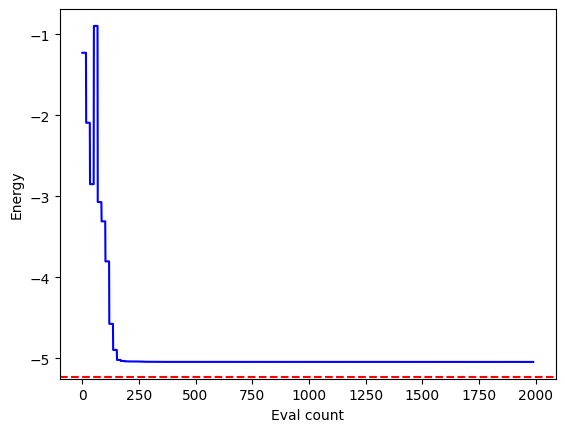

In [ ]:
plt.plot(counts,values,color='blue',linestyle='-')
plt.axhline(exact_energy,color='red',linestyle='--')
plt.xlabel('Eval count')
plt.ylabel('Energy')
plt.show()

NoiseModel:
  Basis gates: ['cx', 'delay', 'id', 'measure', 'reset', 'rz', 'sx', 'x']
  Instructions with noise: ['id', 'x', 'measure', 'sx', 'cx']
  Qubits with noise: [0, 1, 2, 3, 4]
  Specific qubit errors: [('cx', (0, 1)), ('cx', (1, 2)), ('cx', (2, 3)), ('cx', (3, 4)), ('id', (0,)), ('id', (1,)), ('id', (2,)), ('id', (3,)), ('id', (4,)), ('sx', (0,)), ('sx', (1,)), ('sx', (2,)), ('sx', (3,)), ('sx', (4,)), ('x', (0,)), ('x', (1,)), ('x', (2,)), ('x', (3,)), ('x', (4,)), ('measure', (0,)), ('measure', (1,)), ('measure', (2,)), ('measure', (3,)), ('measure', (4,))]
Noisy Ground Energy:
-5.018523581760991


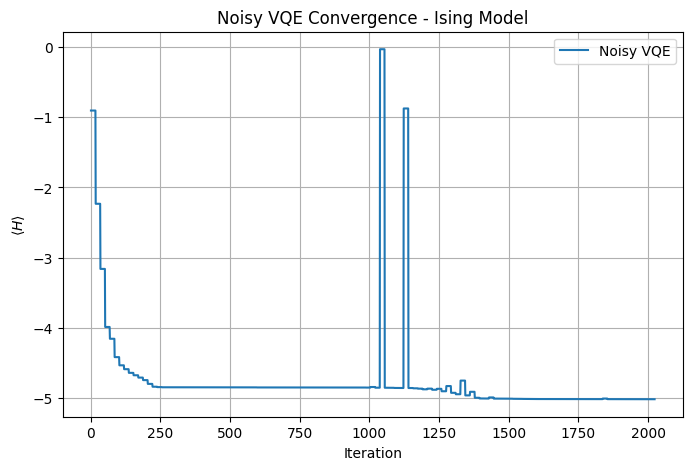

In [ ]:
# ===========================
# Imports
# ===========================

import numpy as np
import matplotlib.pyplot as plt

from qiskit.compiler import transpile

from qiskit.quantum_info import SparsePauliOp

from qiskit_aer.primitives import EstimatorV2 as AerEstimator
from qiskit_aer.noise import NoiseModel

from qiskit.providers.fake_provider import GenericBackendV2

from qiskit_algorithms import VQE
from qiskit_algorithms.optimizers import L_BFGS_B



# ===========================
# 1. Define Generic Backend
# ===========================

coupling_map = [
    (0,1),
    (1,2),
    (2,3),
    (3,4)
]


device = GenericBackendV2(
    num_qubits=5,
    coupling_map=coupling_map
)


# Create noise model from fake device
noise_model = NoiseModel.from_backend(device)


print(noise_model)



# ===========================
# 2. Noisy Aer Estimator
# ===========================

noisy_estimator = AerEstimator(
    options={
        "backend_options": {
            "method": "density_matrix",
            "noise_model": noise_model,
            "coupling_map": coupling_map
        }
    }
)



# ===========================
# 3. Transpile Ansatz
# ===========================

transpiled_ansatz = transpile(
    ansatz,
    backend=device,
    optimization_level=1
)



# ===========================
# 4. VQE Callback
# ===========================

values_noisy = []
counts_noisy = []


def callback(eval_count, parameters, mean, metadata):

    values_noisy.append(mean)
    counts_noisy.append(eval_count)



# ===========================
# 5. VQE
# ===========================

optimizer = L_BFGS_B(
    maxiter=100
)


vqe_noisy = VQE(
    estimator=noisy_estimator,
    ansatz=transpiled_ansatz,
    optimizer=optimizer,
    callback=callback
)



# ===========================
# 6. Run VQE
# ===========================

result = vqe_noisy.compute_minimum_eigenvalue(
    hamiltonian
)


energy_noisy = result.eigenvalue.real


print("Noisy Ground Energy:")
print(energy_noisy)



# ===========================
# 7. Plot Convergence
# ===========================

plt.figure(figsize=(8,5))

plt.plot(
    counts_noisy,
    values_noisy,
    label="Noisy VQE"
)

plt.xlabel("Iteration")
plt.ylabel(r"$\langle H \rangle$")
plt.title("Noisy VQE Convergence - Ising Model")

plt.grid()
plt.legend()

plt.show()

In [ ]:
from qiskit.quantum_info import state_fidelity,Statevector

# Usage: fidelity = state_fidelity(ideal_state, noisy_state)

In [ ]:
from qiskit.quantum_info import Statevector, state_fidelity, partial_trace

# 1. Get your 4-qubit exact eigenvector (Shape: 16)
x, eig = np.linalg.eigh(hamiltonian.to_matrix())
eigenvector = Statevector(eig[:, 0])

# 2. Get the 5-qubit transpiled state vector (Shape: 32)
circuit = transpiled_ansatz.assign_parameters(result.optimal_parameters)
wave_5q = Statevector.from_instruction(circuit)

# 3. FIX: Trace out the 5th qubit (index 4) to bring it back to 4 qubits (Shape: 16)
# Since state_fidelity needs a Statevector or DensityMatrix, tracking it as a
# density matrix after partial_trace is perfectly fine.
wave_4q = partial_trace(wave_5q, [4])

# 4. Compute the fidelity safely
fidelity = state_fidelity(wave_4q, eigenvector)
print("Ideal State Fidelity at Noisy Optima:", fidelity)

Ideal State Fidelity at Noisy Optima: 0.6121476573888343


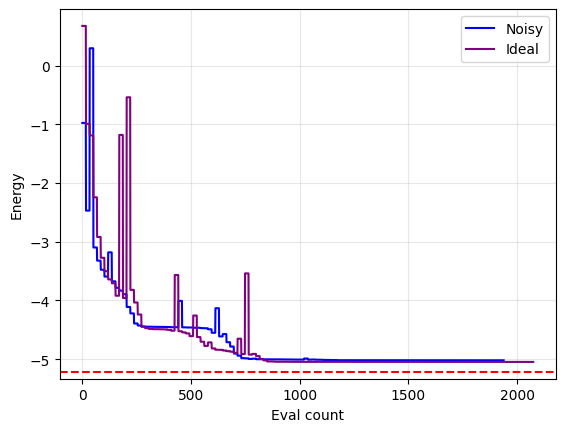

In [ ]:
plt.plot(counts_noisy,values_noisy,color='blue',linestyle='-',label='Noisy')
plt.plot(counts,values,color='purple',linestyle='-',label='Ideal')
plt.axhline(exact_energy,color='red',linestyle='--')
plt.xlabel('Eval count')
plt.ylabel('Energy')
plt.legend()
plt.grid(True,alpha=0.3)
plt.show()

HUBBARD MODEL
$$H = -t \sum_{\sigma=\uparrow,\downarrow} (c^\dagger_{0,\sigma}c_{1,\sigma} + c^\dagger_{1,\sigma}c_{0,\sigma}) + U \sum_{i=0}^{1} n_{i,\uparrow}n_{i,\downarrow}$$

In [ ]:
t=1.0
U=4.0
pauli_terms=[
    ("XZXI", -t / 2),
    ("YZYI", -t / 2),
    ("IXZX", -t / 2),
    ("IYZY", -t / 2),


    ("IIII", 2 * (U / 4)),
    ("IIIZ", -U / 4),
    ("IIZI", -U / 4),
    ("IZII", -U / 4),
    ("ZIII", -U / 4),
    ("IIZZ",  U / 4),
    ("ZZII",  U / 4),

]

qubit_hamil=SparsePauliOp.from_list(pauli_terms)
print(qubit_hamil)

SparsePauliOp(['XZXI', 'YZYI', 'IXZX', 'IYZY', 'IIII', 'IIIZ', 'IIZI', 'IZII', 'ZIII', 'IIZZ', 'ZZII'],
              coeffs=[-0.5+0.j, -0.5+0.j, -0.5+0.j, -0.5+0.j,  2. +0.j, -1. +0.j, -1. +0.j,
 -1. +0.j, -1. +0.j,  1. +0.j,  1. +0.j])


In [ ]:
ansatz=TwoLocal(
    num_qubits=4,
    rotation_blocks=['ry','rz'],
    entanglement_blocks='cx',
    entanglement='linear',
    reps=2
)
counts=[]
values=[]

def callback(eval_count, parameters, mean, std):

    counts.append(eval_count)
    values.append(mean)


optimizer=L_BFGS_B(maxiter=300)
estimator=Estimator()
vqe=VQE(
    estimator=estimator,
    ansatz=ansatz,
    optimizer=optimizer,
    callback=callback
)

/tmp/ipykernel_7291/2718622717.py:1: DeprecationWarning: The class ``qiskit.circuit.library.n_local.two_local.TwoLocal`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.n_local instead.
  ansatz=TwoLocal(


In [ ]:
RESULT=vqe.compute_minimum_eigenvalue(qubit_hamil).eigenvalue.real
print(RESULT)

-0.9999999999178305


In [ ]:
exact_energy=np.linalg.eigvalsh(qubit_hamil.to_matrix())
x=min(exact_energy)
x


np.float64(-1.0)

<>:5: SyntaxWarning: invalid escape sequence '\l'
<>:5: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_7291/3732977898.py:5: SyntaxWarning: invalid escape sequence '\l'
  plt.ylabel('Energy expectation value $\langle H \\rangle$',fontsize=12)


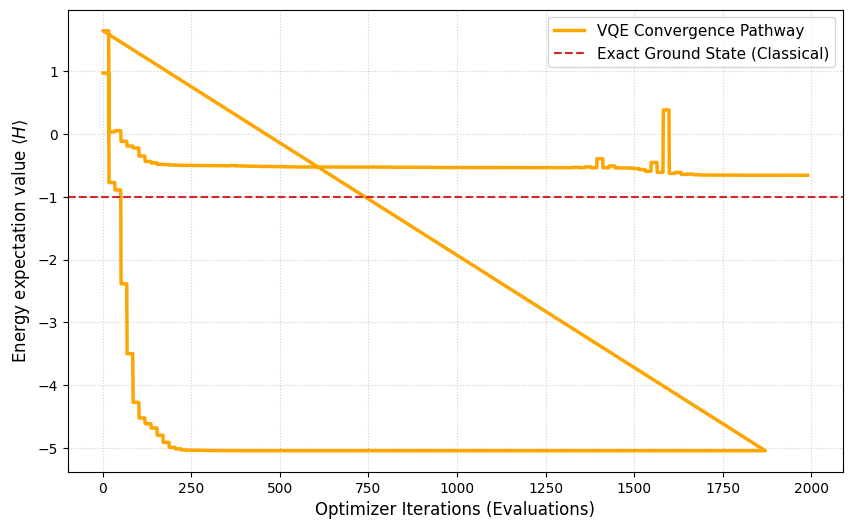

In [ ]:
plt.figure(figsize=(10,6))
plt.plot(counts,values,'-',label='VQE Convergence Pathway',color='orange',lw=2.5)
plt.axhline(y=x,color='#d62728',linestyle='--',label='Exact Ground State (Classical)')
plt.xlabel('Optimizer Iterations (Evaluations)',fontsize=12)
plt.ylabel('Energy expectation value $\langle H \\rangle$',fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=11,loc='upper right')
plt.show()

NoiseModel:
  Basis gates: ['cx', 'delay', 'id', 'measure', 'reset', 'rz', 'sx', 'x']
  Instructions with noise: ['id', 'x', 'measure', 'sx', 'cx']
  Qubits with noise: [0, 1, 2, 3, 4]
  Specific qubit errors: [('cx', (0, 1)), ('cx', (1, 2)), ('cx', (2, 3)), ('cx', (3, 4)), ('id', (0,)), ('id', (1,)), ('id', (2,)), ('id', (3,)), ('id', (4,)), ('sx', (0,)), ('sx', (1,)), ('sx', (2,)), ('sx', (3,)), ('sx', (4,)), ('x', (0,)), ('x', (1,)), ('x', (2,)), ('x', (3,)), ('x', (4,)), ('measure', (0,)), ('measure', (1,)), ('measure', (2,)), ('measure', (3,)), ('measure', (4,))]
Noisy Ground Energy:
-5.0016217688293185


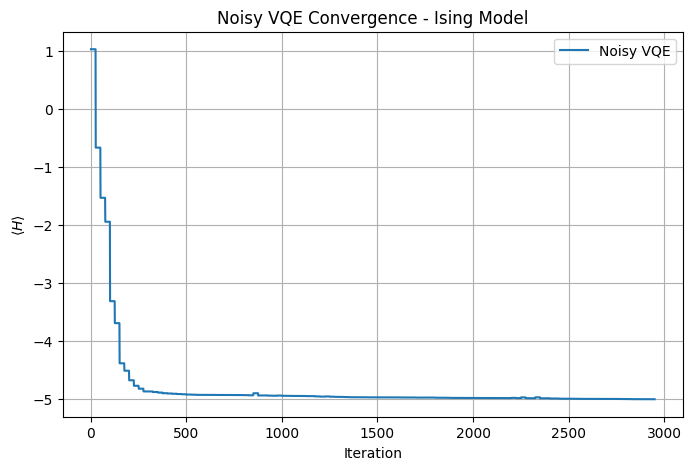

In [ ]:
# ===========================
# Imports
# ===========================

import numpy as np
import matplotlib.pyplot as plt

from qiskit.compiler import transpile

from qiskit.quantum_info import SparsePauliOp

from qiskit_aer.primitives import EstimatorV2 as AerEstimator
from qiskit_aer.noise import NoiseModel

from qiskit.providers.fake_provider import GenericBackendV2

from qiskit_algorithms import VQE
from qiskit_algorithms.optimizers import L_BFGS_B



# ===========================
# 1. Define Generic Backend
# ===========================

coupling_map = [
    (0,1),
    (1,2),
    (2,3),
    (3,4)
]


device = GenericBackendV2(
    num_qubits=5,
    coupling_map=coupling_map
)


# Create noise model from fake device
noise_model = NoiseModel.from_backend(device)


print(noise_model)



# ===========================
# 2. Noisy Aer Estimator
# ===========================

noisy_estimator = AerEstimator(
    options={
        "backend_options": {
            "method": "density_matrix",
            "noise_model": noise_model,
            "coupling_map": coupling_map
        }
    }
)



# ===========================
# 3. Transpile Ansatz
# ===========================

transpiled_ansatz = transpile(
    ansatz,
    backend=device,
    optimization_level=1
)



# ===========================
# 4. VQE Callback
# ===========================

values_noisy = []
counts_noisy = []


def callback(eval_count, parameters, mean, metadata):

    values_noisy.append(mean)
    counts_noisy.append(eval_count)



# ===========================
# 5. VQE
# ===========================

optimizer = L_BFGS_B(
    maxiter=100
)


vqe_noisy = VQE(
    estimator=noisy_estimator,
    ansatz=transpiled_ansatz,
    optimizer=optimizer,
    callback=callback
)



# ===========================
# 6. Run VQE
# ===========================

result = vqe_noisy.compute_minimum_eigenvalue(
    hamiltonian
)


energy_noisy = result.eigenvalue.real


print("Noisy Ground Energy:")
print(energy_noisy)



# ===========================
# 7. Plot Convergence
# ===========================

plt.figure(figsize=(8,5))

plt.plot(
    counts_noisy,
    values_noisy,
    label="Noisy VQE"
)

plt.xlabel("Iteration")
plt.ylabel(r"$\langle H \rangle$")
plt.title("Noisy VQE Convergence - Ising Model")

plt.grid()
plt.legend()

plt.show()

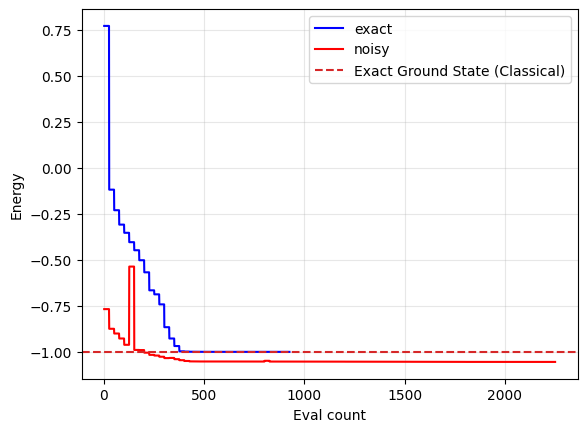

In [ ]:
plt.plot(counts,values,color='blue',linestyle='-',label='exact')
plt.plot(counts_noisy,values_noisy,color='red',linestyle='-',label='noisy')
plt.axhline(y=x,color='#d62728',linestyle='--',label='Exact Ground State (Classical)')
plt.xlabel('Eval count')
plt.ylabel('Energy')
plt.legend()
plt.grid(True,alpha=0.3)
plt.show()

In [ ]:
from qiskit.quantum_info import Statevector, state_fidelity, partial_trace

# 1. Get your 4-qubit exact eigenvector (Shape: 16)
x, eig = np.linalg.eigh(hamiltonian.to_matrix())
eigenvector = Statevector(eig[:, 0])

# 2. Get the 5-qubit transpiled state vector (Shape: 32)
circuit = transpiled_ansatz.assign_parameters(result.optimal_parameters)
wave_5q = Statevector.from_instruction(circuit)

# 3. FIX: Trace out the 5th qubit (index 4) to bring it back to 4 qubits (Shape: 16)
# Since state_fidelity needs a Statevector or DensityMatrix, tracking it as a
# density matrix after partial_trace is perfectly fine.
wave_4q = partial_trace(wave_5q, [4])

# 4. Compute the fidelity safely
fidelity = state_fidelity(wave_4q, eigenvector)
print("Ideal State Fidelity at Noisy Optima:", fidelity)


Ideal State Fidelity at Noisy Optima: 0.6127585625825915


In [ ]:
#HYDROGEN MOLECULE H2

In [ ]:
#molecular geometry
driver=PySCFDriver(atom='H 0 0 0 ;H 0 0 0.735')
problem=driver.run()
hamiltonian=problem.hamiltonian
second_quantized_hamiltonian=hamiltonian.second_q_op()
mapper=JordanWignerMapper()
hamiltonian=mapper.map(second_quantized_hamiltonian)
estimator=Estimator()
values=[]
counts=[]
def callback(eval_count, parameters, mean, std):
    values.append(mean)
    counts.append(eval_count)
initial_state=HartreeFock(
    num_spatial_orbitals=problem.num_spatial_orbitals,
    num_particles=problem.num_particles,
    qubit_mapper=JordanWignerMapper()
)
ansatz=UCCSD(
    num_spatial_orbitals=problem.num_spatial_orbitals,
    num_particles=problem.num_particles,
    qubit_mapper=JordanWignerMapper(),
    initial_state=initial_state

)
vqe_uccsd=VQE(
    estimator=estimator,
    ansatz=ansatz,
    optimizer=L_BFGS_B(maxiter=100),
    callback=callback,
    initial_point=None
            )


In [ ]:
vqe_energy=vqe_uccsd.compute_minimum_eigenvalue(hamiltonian).eigenvalue.real
print(vqe_energy)
exact_energy=min(np.linalg.eigvalsh(hamiltonian))
print(exact_energy)

/usr/local/lib/python3.12/dist-packages/scipy/sparse/linalg/_dsolve/linsolve.py:606: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
/usr/local/lib/python3.12/dist-packages/scipy/sparse/linalg/_matfuncs.py:707: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  return spsolve(Q, P)


-1.857275030197787
-1.8572750302023797


NoiseModel:
  Basis gates: ['cx', 'delay', 'id', 'measure', 'reset', 'rz', 'sx', 'x']
  Instructions with noise: ['id', 'x', 'measure', 'sx', 'cx']
  Qubits with noise: [0, 1, 2, 3, 4]
  Specific qubit errors: [('cx', (0, 1)), ('cx', (1, 2)), ('cx', (2, 3)), ('cx', (3, 4)), ('id', (0,)), ('id', (1,)), ('id', (2,)), ('id', (3,)), ('id', (4,)), ('sx', (0,)), ('sx', (1,)), ('sx', (2,)), ('sx', (3,)), ('sx', (4,)), ('x', (0,)), ('x', (1,)), ('x', (2,)), ('x', (3,)), ('x', (4,)), ('measure', (0,)), ('measure', (1,)), ('measure', (2,)), ('measure', (3,)), ('measure', (4,))]
Noisy Ground Energy:
-1.5315940676491224


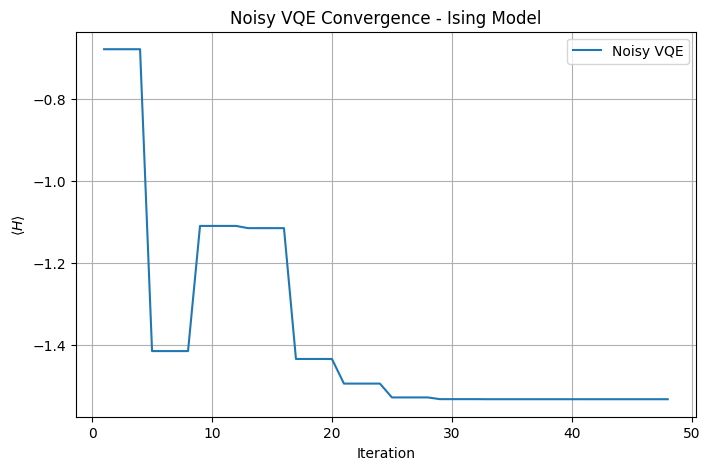

In [ ]:
# ===========================
# Imports
# ===========================

import numpy as np
import matplotlib.pyplot as plt

from qiskit.compiler import transpile

from qiskit.quantum_info import SparsePauliOp

from qiskit_aer.primitives import EstimatorV2 as AerEstimator
from qiskit_aer.noise import NoiseModel

from qiskit.providers.fake_provider import GenericBackendV2

from qiskit_algorithms import VQE
from qiskit_algorithms.optimizers import L_BFGS_B



# ===========================
# 1. Define Generic Backend
# ===========================

coupling_map = [
    (0,1),
    (1,2),
    (2,3),
    (3,4)
]


device = GenericBackendV2(
    num_qubits=5,
    coupling_map=coupling_map
)


# Create noise model from fake device
noise_model = NoiseModel.from_backend(device)


print(noise_model)



# ===========================
# 2. Noisy Aer Estimator
# ===========================

noisy_estimator = AerEstimator(
    options={
        "backend_options": {
            "method": "density_matrix",
            "noise_model": noise_model,
            "coupling_map": coupling_map
        }
    }
)



# ===========================
# 3. Transpile Ansatz
# ===========================

transpiled_ansatz = transpile(
    ansatz,
    backend=device,
    initial_layout=[0, 1, 2, 3],
    optimization_level=1
)



# ===========================
# 4. VQE Callback
# ===========================

values_noisy = []
counts_noisy = []


def callback(eval_count, parameters, mean, metadata):

    values_noisy.append(mean)
    counts_noisy.append(eval_count)



# ===========================
# 5. VQE
# ===========================

optimizer = L_BFGS_B(
    maxiter=100
)


vqe_noisy = VQE(
    estimator=noisy_estimator,
    ansatz=transpiled_ansatz,
    optimizer=optimizer,
    callback=callback
)



# ===========================
# 6. Run VQE
# ===========================

result = vqe_noisy.compute_minimum_eigenvalue(
    hamiltonian
)


energy_noisy = result.eigenvalue.real


print("Noisy Ground Energy:")
print(energy_noisy)



# ===========================
# 7. Plot Convergence
# ===========================

plt.figure(figsize=(8,5))

plt.plot(
    counts_noisy,
    values_noisy,
    label="Noisy VQE"
)

plt.xlabel("Iteration")
plt.ylabel(r"$\langle H \rangle$")
plt.title("Noisy VQE Convergence - Ising Model")

plt.grid()
plt.legend()

plt.show()

In [ ]:

# 1. Get your 4-qubit exact eigenvector (Shape: 16)
x, eig = np.linalg.eigh(hamiltonian.to_matrix())
eigenvector = Statevector(eig[:, 0])

# 2. Get the 5-qubit transpiled state vector (Shape: 32)
circuit = transpiled_ansatz.assign_parameters(result.optimal_parameters)
wave_5q = Statevector.from_instruction(circuit)

# 3. FIX: Trace out the 5th qubit (index 4) to bring it back to 4 qubits (Shape: 16)
# Since state_fidelity needs a Statevector or DensityMatrix, tracking it as a
# density matrix after partial_trace is perfectly fine.
wave_4q = partial_trace(wave_5q, [4])

# 4. Compute the fidelity safely
fidelity = state_fidelity(wave_4q, eigenvector)
print("Ideal State Fidelity at Noisy Optima:", fidelity)

Ideal State Fidelity at Noisy Optima: 0.9997298278656743


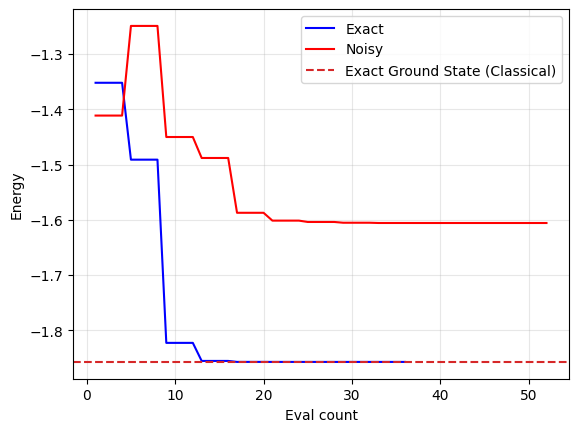

In [ ]:
plt.plot(counts,values,color='blue',linestyle='-',label='Exact')
plt.plot(counts_noisy,values_noisy,color='red',linestyle='-',label='Noisy')
plt.axhline(y=exact_energy,color='#d62728',linestyle='--',label='Exact Ground State (Classical)')
plt.xlabel('Eval count')
plt.ylabel('Energy')
plt.legend()
plt.grid(True,alpha=0.3)
plt.show()

LiH

In [ ]:
driver=PySCFDriver(atom='Li 0 0 0; H 0 0 1.595')
problem=driver.run()
hamiltonian=problem.hamiltonian
transformer = ActiveSpaceTransformer(num_electrons=2, num_spatial_orbitals=2)
reduced_problem = transformer.transform(problem)
problem_hamiltonian = reduced_problem.hamiltonian
second_q_hamil=problem_hamiltonian.second_q_op()
mapper=JordanWignerMapper()
hamiltonian=mapper.map(second_q_hamil)

In [ ]:
nuclear_repulsion = problem_hamiltonian.constants.get("nuclear_repulsion_energy", 0.0)
energy_shift = problem_hamiltonian.constants.get("ActiveSpaceTransformer", 0.0)
print(nuclear_repulsion)
print(energy_shift)
constant_shift = nuclear_repulsion + energy_shift
print(constant_shift)

0.995317638094044
-7.798291188105949
-6.802973550011905


In [ ]:
values_uccsd=[]
counts_uccsd=[]

def callback(eval_count,parameters,mean,std):
    counts_uccsd.append(eval_count)
    values_uccsd.append(mean)

initial_state=HartreeFock(
    num_spatial_orbitals=reduced_problem.num_spatial_orbitals,
    num_particles=reduced_problem.num_particles,
    qubit_mapper=mapper

)

ansatz=UCCSD(
    num_spatial_orbitals=reduced_problem.num_spatial_orbitals,
    num_particles=reduced_problem.num_particles,
    qubit_mapper=mapper,
    initial_state=initial_state
)
estimator=Estimator()
vqe=VQE(
    estimator=estimator,
    ansatz=ansatz,
    optimizer=L_BFGS_B(maxiter=100),
    callback=callback,
    initial_point=None
)

In [ ]:
vqe_energy_uccsd=vqe.compute_minimum_eigenvalue(hamiltonian)
total_energy_uccsd=vqe_energy_uccsd.eigenvalue.real+constant_shift
print(total_energy_uccsd)

/usr/local/lib/python3.12/dist-packages/scipy/sparse/linalg/_dsolve/linsolve.py:606: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
/usr/local/lib/python3.12/dist-packages/scipy/sparse/linalg/_matfuncs.py:707: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  return spsolve(Q, P)


-7.862285533924413


In [ ]:
exact_energy=np.linalg.eigvalsh(hamiltonian.to_matrix())[0]+constant_shift
print(exact_energy)

-7.8622855339281665


In [ ]:
vqe_energies=[raw_energy+constant_shift for raw_energy in values_uccsd]

NoiseModel:
  Basis gates: ['cx', 'delay', 'id', 'measure', 'reset', 'rz', 'sx', 'x']
  Instructions with noise: ['id', 'x', 'measure', 'sx', 'cx']
  Qubits with noise: [0, 1, 2, 3, 4]
  Specific qubit errors: [('cx', (0, 1)), ('cx', (1, 2)), ('cx', (2, 3)), ('cx', (3, 4)), ('id', (0,)), ('id', (1,)), ('id', (2,)), ('id', (3,)), ('id', (4,)), ('sx', (0,)), ('sx', (1,)), ('sx', (2,)), ('sx', (3,)), ('sx', (4,)), ('x', (0,)), ('x', (1,)), ('x', (2,)), ('x', (3,)), ('x', (4,)), ('measure', (0,)), ('measure', (1,)), ('measure', (2,)), ('measure', (3,)), ('measure', (4,))]
Noisy Ground Energy:
-7.7736690087518046


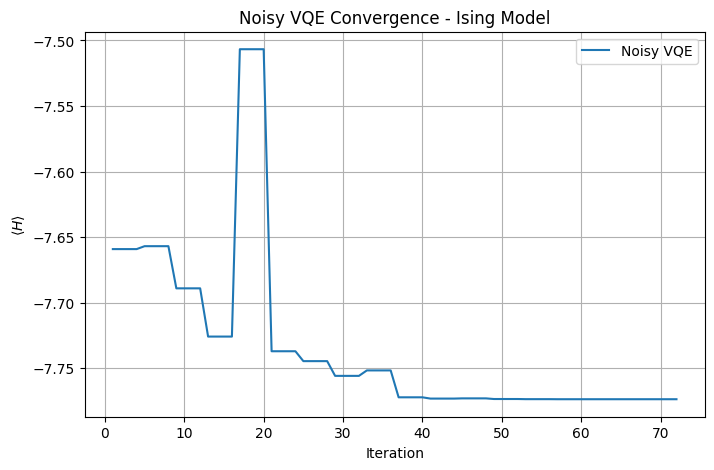

In [ ]:
# ===========================
# Imports
# ===========================

import numpy as np
import matplotlib.pyplot as plt

from qiskit.compiler import transpile

from qiskit.quantum_info import SparsePauliOp

from qiskit_aer.primitives import EstimatorV2 as AerEstimator
from qiskit_aer.noise import NoiseModel

from qiskit.providers.fake_provider import GenericBackendV2

from qiskit_algorithms import VQE
from qiskit_algorithms.optimizers import L_BFGS_B



# ===========================
# 1. Define Generic Backend
# ===========================

coupling_map = [
    (0,1),
    (1,2),
    (2,3),
    (3,4)
]


device = GenericBackendV2(
    num_qubits=5,
    coupling_map=coupling_map
)


# Create noise model from fake device
noise_model = NoiseModel.from_backend(device)


print(noise_model)



# ===========================
# 2. Noisy Aer Estimator
# ===========================

noisy_estimator = AerEstimator(
    options={
        "backend_options": {
            "method": "density_matrix",
            "noise_model": noise_model,
            "coupling_map": coupling_map
        }
    }
)



# ===========================
# 3. Transpile Ansatz
# ===========================

transpiled_ansatz = transpile(
    ansatz,
    backend=device,
    optimization_level=1
)



# ===========================
# 4. VQE Callback
# ===========================

values_noisy = []
counts_noisy = []


def callback(eval_count, parameters, mean, metadata):

    values_noisy.append(mean)
    counts_noisy.append(eval_count)



# ===========================
# 5. VQE
# ===========================

optimizer = L_BFGS_B(
    maxiter=100
)


vqe_noisy = VQE(
    estimator=noisy_estimator,
    ansatz=transpiled_ansatz,
    optimizer=optimizer,
    callback=callback
)



# ===========================
# 6. Run VQE
# ===========================

result = vqe_noisy.compute_minimum_eigenvalue(
    hamiltonian
)


energy_noisy = result.eigenvalue.real+constant_shift


print("Noisy Ground Energy:")
print(energy_noisy)

vqe_noisy_energies=[raw+constant_shift for raw in values_noisy]



# ===========================
# 7. Plot Convergence
# ===========================

plt.figure(figsize=(8,5))

plt.plot(
    counts_noisy,
    vqe_noisy_energies,
    label="Noisy VQE"
)

plt.xlabel("Iteration")
plt.ylabel(r"$\langle H \rangle$")
plt.title("Noisy VQE Convergence - Ising Model")

plt.grid()
plt.legend()

plt.show()

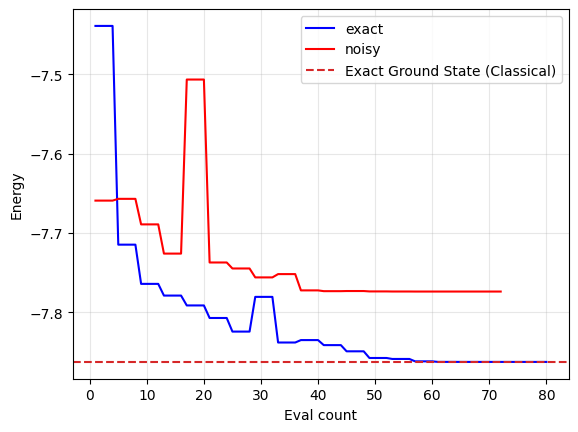

In [ ]:
plt.plot(counts_uccsd,vqe_energies,color='blue',linestyle='-',label='exact')
plt.plot(counts_noisy,vqe_noisy_energies,color='red',linestyle='-',label='noisy')
plt.axhline(y=exact_energy,color='#d62728',linestyle='--',label='Exact Ground State (Classical)')
plt.xlabel('Eval count')
plt.ylabel('Energy')
plt.grid(True,alpha=0.3)
plt.legend()
plt.show()

In [ ]:

from qiskit.quantum_info import DensityMatrix, state_fidelity, partial_trace
from qiskit_aer import AerSimulator
from qiskit import QuantumCircuit
import numpy as np

# ----------------------------------------------------------
# Step 1: Ideal ground-state eigenvector (4-qubit, pure)
# ----------------------------------------------------------
eigenvalues, eigenvectors = np.linalg.eigh(hamiltonian.to_matrix())
ideal_state = DensityMatrix(eigenvectors[:, 0])   # pure state as DensityMatrix

# ----------------------------------------------------------
# Step 2: Build the circuit for the noisy simulation
#   - Use the transpiled ansatz with optimal parameters found
#     by noisy VQE, and append a save_density_matrix instruction
# ----------------------------------------------------------
circuit_for_dm = transpiled_ansatz.assign_parameters(result.optimal_parameters)
circuit_for_dm.save_density_matrix()   # tells AerSimulator to save the full ρ

# ----------------------------------------------------------
# Step 3: Run through AerSimulator WITH noise model
#   This is what your noisy estimator used internally, so this
#   gives the true noisy output state.
# ----------------------------------------------------------
sim = AerSimulator(
    method="density_matrix",
    noise_model=noise_model,
    coupling_map=coupling_map
)

job = sim.run(circuit_for_dm, shots=1)   # shots=1 is fine; density_matrix is exact
sim_result = job.result()

# Full density matrix over all 5 qubits (2^5 × 2^5 = 32×32)
dm_5q = DensityMatrix(sim_result.data(0)["density_matrix"])

# ----------------------------------------------------------
# Step 4: Trace out the ancilla qubit (qubit index 4)
#   partial_trace keeps all qubits EXCEPT the one(s) listed.
#   After tracing out qubit 4, we have a 4-qubit (16×16) ρ.
# ----------------------------------------------------------
# Note: Qiskit's partial_trace qubit ordering is 0 = least significant.
# The extra transpiled qubit is index 4 (most significant in 5-qubit space).
dm_4q = partial_trace(dm_5q, [4])   # result is a 4-qubit DensityMatrix

# ----------------------------------------------------------
# Step 5: Compute fidelity F(ρ_noisy, |ψ_ideal⟩)
#   state_fidelity handles mixed vs pure correctly.
# ----------------------------------------------------------
fidelity = state_fidelity(dm_4q, ideal_state)
print(f"True Noisy State Fidelity: {fidelity:.6f}")
print(f"Ideal VQE Energy:  {vqe_energy:.6f} Ha")
print(f"Noisy VQE Energy:  {energy_noisy:.6f} Ha")
print(f"Energy difference: {abs(energy_noisy - vqe_energy)*1000:.3f} mHa")

True Noisy State Fidelity: 0.746042
Ideal VQE Energy:  -1.857275 Ha
Noisy VQE Energy:  -7.773669 Ha
Energy difference: 5916.394 mHa
